## Importing Dependencies

In [34]:
import sys
import os
# Add parent directory ('notebooks') to the search path
sys.path.append(os.path.abspath(os.path.join('..')))


from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document

from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import openai

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message


from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PayloadSchemaType, PointStruct, SparseVectorParams, Document, Prefetch, FusionQuery
from qdrant_client import models

import pandas as pd
import openai
import fastembed


In [35]:
from qdrant_client import QdrantClient
qdrant_client = QdrantClient(url="http://localhost:6333")

In [36]:
@traceable(
    name="get_embedding",
    run_type="embedding",
    metadata={
        "ls_model": "openai/text-embedding-3-small",
        "ls_provider": "openai",
        "ls_model_type": "embedding"
        }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=[text],
        model=model,
    )
    return response.data[0].embedding

In [37]:
@traceable(
    name="retrieve_data",
    run_type="retriever",
    metadata={
        "ls_provider": "qdrant",

    }
)
def retrieve_data(query, k=5):

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name="Products-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=k,
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "retrieved_context_ratings": retrieved_context_ratings,
        "similarity_scores": similarity_scores,
    }


In [38]:
results = retrieve_data("Can I get some shampoo?", k=20)

In [39]:
results

{'retrieved_context_ids': ['B08V131NBS',
  'B002ZGQ998',
  'B086HRN773',
  'B00899F1V2',
  'B08Z36ZWVP',
  'B006R0ZEN0',
  'B07NDLXGN2',
  'B007TOLSSI',
  'B07L3N6RPY',
  'B00E3G3Z6I',
  'B07VMGV3SK',
  'B01N1G9RLR',
  'B019H3S566',
  'B00LKL4FP4',
  'B00G9XOYMM',
  'B09CT5S7J1',
  'B07NZ8PWWD',
  'B00ITV1556',
  'B00NQ44Y0O',
  'B002SQ0KD6'],
 'retrieved_context': ['Why Shampoo Bar? Conventional shampoos are harsh on the hair. They use strong petroleum-based detergents that strip the hair of natural protective oils. Silicone-based ingredients are then added to give hair a shiny shine for a healthy appearance. Specifications: Name: handmade shampoo soap Condition: new Net Weight:60g Package Includes: 2 * natural shampoo soap',
  'Oasis Shampoo Cap',
  'John Frieda Coconut Oil Infused Frizz Ease Shampoo and Conditioner is formulated to build up your resistance to dry, damaged, frizzy hair while making it more manageable and easily styled. Fight frizz and flyaways before they start with 

## Query Expansion

In [40]:
class QueryExpandResponse(BaseModel):
    expanded_query: List[str] = Field(
        ..., 
        max_length=4, 
        description="A list of 3 to 4 expanded search queries. Do not exceed 4 items.")

In [41]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider":"openai","ls_model_name":"gpt-4o-mini"}
)
def query_expand_node(query:str) -> dict:
    
    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.

<Question>
{{ query }}
</Question>
"""
    
    template = Template(prompt_template)
    
    prompt = template.render(
        query=query
    )
    
    client = instructor.from_openai(OpenAI())
    
    # NOTE: "gpt-4.1-mini" in the screenshot has a typo. 
    # Use "gpt-4o-mini" to target the correct OpenAI model.
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )
    
    return {
        "expanded_query": response.expanded_query
    }


In [42]:
results = query_expand_node( "What are some affordable shampoos that also protect color-treated hair?")

In [43]:
results

{'expanded_query': ['Affordable shampoos for color-treated hair',
  'Budget-friendly hair care products that protect color-treated hair',
  'Low-cost shampoos that help maintain hair color',
  'Inexpensive shampoos suitable for colored hair']}

# LangGraph Integration

### Query Expansion (Sequential Execution)

In [15]:
class State(BaseModel):
    expanded_query:List[str]=[]
    retrieved_context:Annotated[List[str],add]=[]
    initial_query:str=''
    answer:str=''


In [16]:
class QueryExpandResponse(BaseModel):
    expanded_query: List[str] = Field(
        ..., 
        max_length=4, 
        description="A list of 3 to 4 expanded search queries. Do not exceed 4 items.")

In [18]:

@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider":"openai","ls_model_name":"gpt-4o-mini"}
)
def query_expand_node(state:State) -> dict:
    
    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.

<Question>
{{ query }}
</Question>
"""
    
    template = Template(prompt_template)
    
    prompt = template.render(
        query=state.initial_query
    )
    
    client = instructor.from_openai(OpenAI())
    
    # NOTE: "gpt-4.1-mini" in the screenshot has a typo. 
    # Use "gpt-4o-mini" to target the correct OpenAI model.
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )
    
    return {
        "expanded_query": response.expanded_query
    }


In [26]:
@traceable(
    name="get_embedding",
    run_type="embedding",
    metadata={
        "ls_model": "openai/text-embedding-3-small",
        "ls_provider": "openai",
        "ls_model_type": "embedding"
        }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=[text],
        model=model,
    )
    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever",
    metadata={
        "ls_provider": "qdrant",

    }
)
def retrieve_data(query, k=5):

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name="Products-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=k,
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    formatted_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
        
    return formatted_context

@traceable(
    name="retriever_node",
    run_type="retriever",
    metadata={
        "ls_model": "openai/text-embedding-3-small",
        "ls_provider": "openai",
        "ls_model_type": "embedding"
        }
)
def retriever_node(state:State):
    retrieved_context=[]

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query,k=5))


    return {
        "retrieved_context":retrieved_context
    }
    

# Aggregator Node

In [20]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")

@traceable(
    name="aggregator_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4o-mini"}
)
def aggregator_node(state: State) -> dict:
    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use the word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

    template = Template(prompt_template)
    
    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )
    
    client = instructor.from_openai(OpenAI())
    
    # Note: Using AggregatorResponse instead of QueryExpandResponse
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini",
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )
    
    return {
        "answer": response.answer
    }


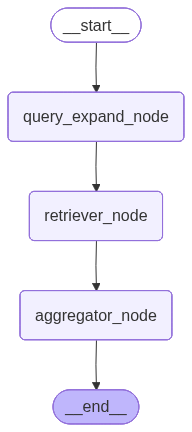

In [23]:
workflow = StateGraph(State)

workflow.add_node("aggregator_node",aggregator_node)
workflow.add_node("retriever_node",retriever_node)
workflow.add_node("query_expand_node",query_expand_node)


workflow.add_edge(START,"query_expand_node")
workflow.add_edge("query_expand_node","retriever_node")
workflow.add_edge("retriever_node","aggregator_node")
workflow.add_edge("aggregator_node",END)


graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [27]:

query = "What are some affordable shampoos that also protect color-treated hair?"

initial_state = {
    "initial_query":query
}

In [28]:
result = graph.invoke(initial_state)

In [32]:
result

{'expanded_query': ['Affordable shampoos for color-treated hair',
  'Budget-friendly shampoos that protect hair color',
  'Inexpensive shampoos designed for colored hair',
  'Cost-effective hair care products for color protection'],
 'retrieved_context': ["- ID: B0011DN60Q, rating: 3.8, description: Formula for healthy hair and scalp, safe for the chemically sensitive and colored or treated hair.\n- ID: B00G9XOYMM, rating: 4.6, description: Help protect your color-treated hair against dryness and fading with Pantene Pro-V Color Revival 2in1 Shampoo and Conditioner. This color 2 in 1 shampoo and conditioner uses a multitasking formula that both cleanses and hydrates hair and is gentle enough to use every day. In 1 simple step, Color Revival 2in1 Shampoo and Conditioner infuses your hair with brilliant shine and helps protect your color using Chroma Spectrum technology. Also try the treatment and shine spray from the Color Revival Collection to leave your hair looking vibrant.\n- ID: B00

In [33]:
print(result["answer"])

Here are some affordable shampoos that protect color-treated hair:

1. **Pantene Pro-V Color Revival 2in1 Shampoo and Conditioner**  
   - **Rating:** 4.6  
   - **Description:** Helps protect your color-treated hair against dryness and fading. This multitasking formula cleanses and hydrates hair, making it gentle enough for daily use.  
   - **Features:**  
     - Infuses hair with brilliant shine  
     - Uses Chroma Spectrum technology to protect color  
     - Available in a convenient 2-in-1 format  
     - Also includes treatment and shine spray options from the Color Revival Collection for added vibrancy.

2. **Garnier Fructis Color Shield Instant Color Sealer**  
   - **Rating:** 4.4  
   - **Description:** Lightweight leave-in formula that helps to stop dry-out and fight fade-out.  
   - **Features:**  
     - Infused with acai berry and grape seed oil  
     - Instantly seals in color for longer-lasting vibrancy  
     - Improves manageability and delivers lasting softness  


### Query Expansion (Parallel Execution)

In [73]:
class State(BaseModel):
    expanded_query:List[str]=[]
    retrieved_context:Annotated[List[str],add]=[]
    initial_query:str=''
    answer:str=''
    query:str=""
    k:int=10

#### Query Rewriting/ Expansion

In [74]:
class QueryExpandResponse(BaseModel):
    expanded_query: List[str] = Field(
        ..., 
        max_length=4, 
        description="A list of 3 to 4 expanded search queries. Do not exceed 4 items.")

In [75]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider":"openai","ls_model_name":"gpt-4o-mini"}
)
def query_expand_node(state:State) -> dict:
    
    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.

<Question>
{{ query }}
</Question>
"""
    
    template = Template(prompt_template)
    
    prompt = template.render(
        query=state.initial_query
    )
    
    client = instructor.from_openai(OpenAI())
    
    # NOTE: "gpt-4.1-mini" in the screenshot has a typo. 
    # Use "gpt-4o-mini" to target the correct OpenAI model.
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )
    
    return {
        "expanded_query": response.expanded_query
    }


In [ ]:
def query_expand_conditional_edges(state: State):

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retrieve_data_node",
                {
                    "query": query,
                    "k": 10
                }
            )
        )

    return send_messages


#### Retriever Node

In [ ]:
@traceable(
    name="get_embedding",
    run_type="embedding",
    metadata={
        "ls_model": "openai/text-embedding-3-small",
        "ls_provider": "openai",
        "ls_model_type": "embedding"
        }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=[text],
        model=model,
    )
    return response.data[0].embedding


@traceable(
    name="retrieve_data_node",
    run_type="retriever",
    metadata={
        "ls_provider": "qdrant",
    }
)
def retrieve_data_node(state: State):
    query = state.query
    k = state.k

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name="Products-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=k,
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    formatted_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
        
    return {"retrieved_context": [formatted_context]}


#### Aggregator Node

In [78]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")

@traceable(
    name="aggregator_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4o-mini"}
)
def aggregator_node(state: State) -> dict:
    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use the word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

    template = Template(prompt_template)
    
    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )
    
    client = instructor.from_openai(OpenAI())
    
    # Note: Using AggregatorResponse instead of QueryExpandResponse
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini",
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )
    
    return {
        "answer": response.answer
    }


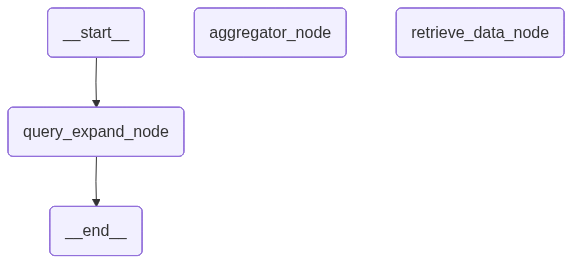

In [79]:
workflow = StateGraph(State)

workflow.add_node("aggregator_node",aggregator_node)
workflow.add_node("retrieve_data_node",retrieve_data_node)
workflow.add_node("query_expand_node",query_expand_node)


workflow.add_edge(START,"query_expand_node")
workflow.add_conditional_edges(
    "query_expand_node", 
    query_expand_conditional_edges
)
workflow.add_edge("retrieve_data_node","aggregator_node")
workflow.add_edge("aggregator_node",END)


graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:

query = "What are some affordable shampoos that also protect color-treated hair?"

initial_state = {
    "initial_query":query
}

In [83]:
results = graph.invoke(initial_state)

BadRequestError: Error code: 400 - {'error': {'message': "Invalid 'input': expected a string array or token array.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [ ]:
results